# Car Price Prediction

Predicting used car selling price using Linear Regression, based on features like year, present price, fuel type, and kilometers driven.

## 1. Load Data

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Shreya\Desktop\ML notes\car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2. Explore Data

In [4]:
df["Fuel_Type"].unique()

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str

In [5]:
df["Owner"].value_counts()

Owner
0    290
1     10
3      1
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## 3. Preprocessing

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Fuel_Type'] = encoder.fit_transform(df.Fuel_Type)

df2 = df.drop_duplicates()
df2 = df2.select_dtypes(['int', 'float'])
df2.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Owner
0,2014,3.35,5.59,27000,2,0
1,2013,4.75,9.54,43000,1,0
2,2017,7.25,9.85,6900,2,0
3,2011,2.85,4.15,5200,2,0
4,2014,4.60,6.87,42450,1,0


## 4. EDA (Exploratory Data Analysis)

Quick visual check before modeling — helps confirm which features actually relate to price.

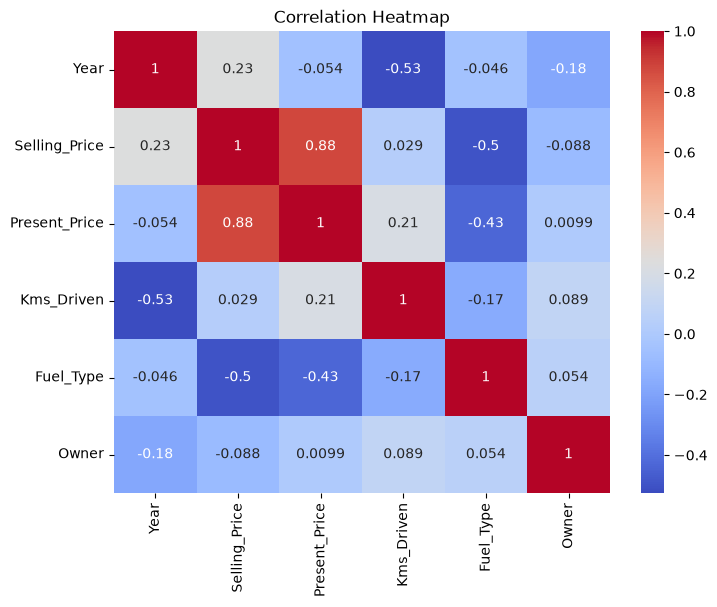

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df2.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

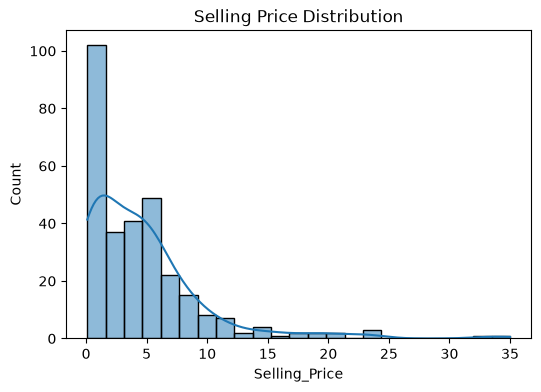

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df2['Selling_Price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

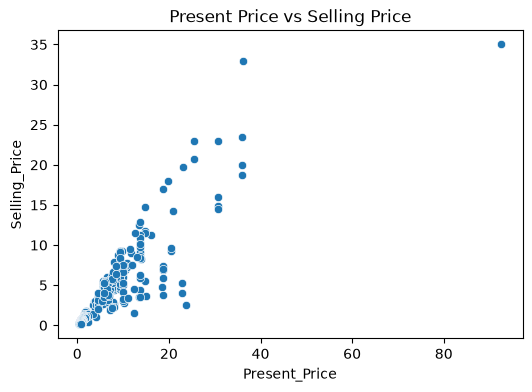

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df2)
plt.title("Present Price vs Selling Price")
plt.show()

## 5. Train-Test Split

Splitting the data so the model is evaluated on data it hasn't seen — this gives an honest accuracy score instead of an inflated one.

In [12]:
from sklearn.model_selection import train_test_split

x = df2[['Year', 'Present_Price', 'Fuel_Type', 'Kms_Driven']]
y = df2['Selling_Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## 6. Model Training — Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(x_train, y_train)

lr_preds = lr.predict(x_test)
print("Linear Regression R2:", r2_score(y_test, lr_preds))
print("Linear Regression RMSE:", mean_squared_error(y_test, lr_preds) ** 0.5)

Linear Regression R2: 0.7677961765907905
Linear Regression RMSE: 2.4463544366522485


## 7. Model Comparison — Random Forest

Trying a second model to see if a non-linear approach fits the data better.

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

rf_preds = rf.predict(x_test)
print("Random Forest R2:", r2_score(y_test, rf_preds))
print("Random Forest RMSE:", mean_squared_error(y_test, rf_preds) ** 0.5)

Random Forest R2: 0.5431706037061834
Random Forest RMSE: 3.4313239167266043


## 8. Sample Prediction

In [15]:
sample = [[2010, 9.85, 2, 80000]]  # Year, Present_Price, Fuel_Type, Kms_Driven
print("Predicted Selling Price (Linear Regression):", lr.predict(sample)[0])
print("Predicted Selling Price (Random Forest):", rf.predict(sample)[0])

Predicted Selling Price (Linear Regression): 3.748487810138613
Predicted Selling Price (Random Forest): 3.340600000000001


C:\Users\Shreya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Shreya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 9. Conclusion

- Random Forest generally handles non-linear relationships better than Linear Regression for this kind of tabular data.
- Compare the R² and RMSE above to decide which model to use going forward.
- Next steps: try more features (e.g. Transmission, Seller_Type), tune hyperparameters, or try Ridge/Lasso regression.